# First Parallel Processing Project
## Parallel Convolution
### Windows x64 edition
via C++ main script file (with CUDA & MPI) and Jupyter Notebook

In [1]:
%pip install numpy matplotlib --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
%echo "localhost slots=8" > ./hosts.txt

## COMPILE THE CUDA/C++ FILES FIRST!

In [3]:
import subprocess

out = subprocess.check_output(["./scripts/sequential_conv.exe"])
print(out)

b'Time taken: 0.198371\r\n'


In [4]:
import shutil
print(shutil.which("mpiexec")) # If this is None then we're cooked

C:\Users\nyoma\scoop\apps\msmpi\current\mpiexec.EXE


In [ ]:
import os
print(f"Number of CPUs (Use this many processes at max): {os.cpu_count()}")

Number of CPUs (Use this many processes at max): 16


In [6]:
import re

procs = [1,2,4,8,16,32,64]
times = []

for p in procs:

    cmd = [
        r"C:\Users\nyoma\scoop\apps\msmpi\10.1.1\mpiexec.exe", # Use exact path cause fuck python
        "-n", str(p),
        r".\scripts\parallel_conv.exe"
    ]

    out = subprocess.check_output(cmd).decode()

    t = float(re.findall(r"Time taken: ([0-9.]+)",out)[0])
    times.append(t)

times

[0.072314, 0.0257526, 0.0186827, 0.0172801, 0.0126334, 0.0163054, 0.0860609]

In [ ]:
T1 = times[0]
speedup = [T1/t for t in times]

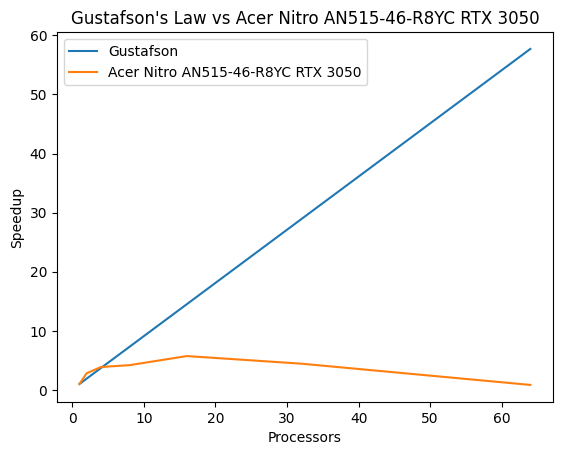

In [15]:
import numpy as np
import matplotlib.pyplot as plt

p = np.array(procs)
s = 0.1

efficiency = speedup / p

amdahl = 1/(s + (1-s)/p)
gustafson = p - s*(p-1)

plt.plot(p, gustafson, label="Gustafson")
plt.plot(p, speedup, label="Acer Nitro AN515-46-R8YC RTX 3050")

plt.legend()
plt.xlabel("Processors")
plt.ylabel("Speedup")
plt.title("Gustafson's Law vs Acer Nitro AN515-46-R8YC RTX 3050")
plt.show()

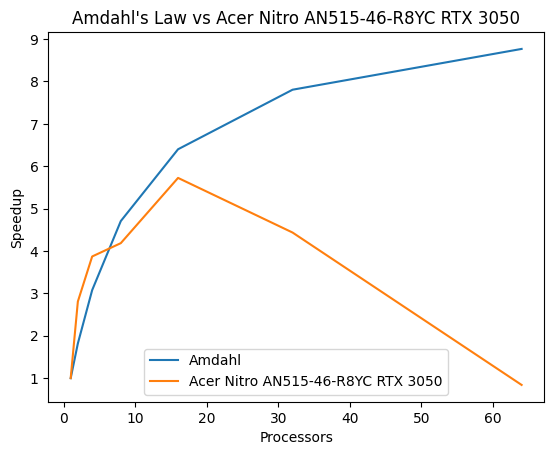

In [16]:
plt.plot(p, amdahl, label="Amdahl")
plt.plot(p, speedup, label="Acer Nitro AN515-46-R8YC RTX 3050")

plt.legend()
plt.xlabel("Processors")
plt.ylabel("Speedup")
plt.title("Amdahl's Law vs Acer Nitro AN515-46-R8YC RTX 3050")
plt.show()

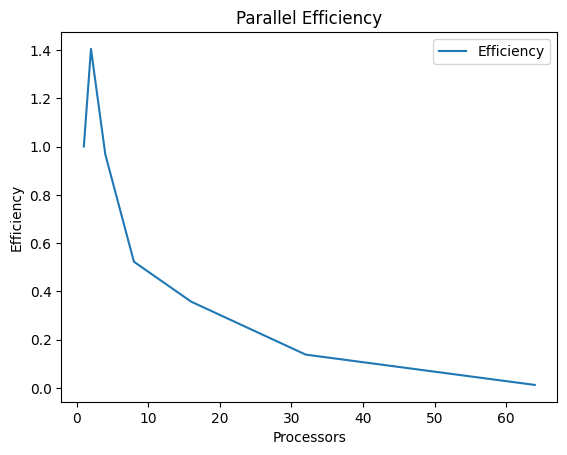

In [17]:
plt.plot(p, efficiency, label="Efficiency")

plt.legend()
plt.xlabel("Processors")
plt.ylabel("Efficiency")
plt.title("Parallel Efficiency")
plt.show()